### Dataset Source: Kaggle (https://www.kaggle.com/datasets/undersc0re/flight-delay-and-causes)


## Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle



## Import Data

In [ ]:
df = pd.read_csv('Flight_delay.csv')
df.head()

/tmp/ipython-input-3254039318.py:1: DtypeWarning: Columns (1,5,6,8,14,15,16,17,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Flight_delay.csv')


,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4.0,3/1/2019,1829.0,1959.0,1925.0,WN,Southwest Airlines Co.,3920.0,N464WN,90.0,...,3.0,10.0,0.0,N,0.0,2.0,0.0,0.0,0.0,32.0
1,4.0,3/1/2019,1937.0,2037.0,1940.0,WN,Southwest Airlines Co.,509.0,N763SW,240.0,...,3.0,7.0,0.0,N,0.0,10.0,0.0,0.0,0.0,47.0
2,4.0,3/1/2019,1644.0,1845.0,1725.0,WN,Southwest Airlines Co.,1333.0,N334SW,121.0,...,6.0,8.0,0.0,N,0.0,8.0,0.0,0.0,0.0,72.0
3,4.0,3/1/2019,1452.0,1640.0,1625.0,WN,Southwest Airlines Co.,675.0,N286WN,228.0,...,7.0,8.0,0.0,N,0.0,3.0,0.0,0.0,0.0,12.0
4,4.0,3/1/2019,1323.0,1526.0,1510.0,WN,Southwest Airlines Co.,4.0,N674AA,123.0,...,4.0,9.0,0.0,N,0.0,0.0,0.0,0.0,0.0,16.0


In [ ]:
df.tail()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
484541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484542,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(484546, 29)

In [ ]:
df.index

RangeIndex(start=0, stop=484546, step=1)

In [ ]:
df.dtypes

,0
DayOfWeek,float64
Date,object
DepTime,float64
ArrTime,float64
CRSArrTime,float64
UniqueCarrier,object
Airline,object
FlightNum,float64
TailNum,object
ActualElapsedTime,float64


In [ ]:
df.info

<bound method DataFrame.info of         DayOfWeek      Date  DepTime  ArrTime  CRSArrTime UniqueCarrier  \
0             4.0  3/1/2019   1829.0   1959.0      1925.0            WN   
1             4.0  3/1/2019   1937.0   2037.0      1940.0            WN   
2             4.0  3/1/2019   1644.0   1845.0      1725.0            WN   
3             4.0  3/1/2019   1452.0   1640.0      1625.0            WN   
4             4.0  3/1/2019   1323.0   1526.0      1510.0            WN   
...           ...       ...      ...      ...         ...           ...   
484541        NaN       NaN      NaN      NaN         NaN           NaN   
484542        NaN       NaN      NaN      NaN         NaN           NaN   
484543        NaN       NaN      NaN      NaN         NaN           NaN   
484544        NaN       NaN      NaN      NaN         NaN           NaN   
484545        NaN       NaN      NaN      NaN         NaN           NaN   

                       Airline  FlightNum TailNum  ActualElapsedTime  ...  \
0       Southwest Airlines Co.     3920.0  N464WN               90.0  ...   
1       Southwest Airlines Co.      509.0  N763SW              240.0  ...   
2       Southwest Airlines Co.     1333.0  N334SW              121.0  ...   
3       Southwest Airlines Co.      675.0  N286WN              228.0  ...   
4       Southwest Airlines Co.        4.0  N674AA              123.0  ...   
...                        ...        ...     ...                ...  ...   
484541                     NaN        NaN     NaN                NaN  ...   
484542                     NaN        NaN     NaN                NaN  ...   
484543                     NaN        NaN     NaN                NaN  ...   
484544                     NaN        NaN     NaN                NaN  ...   
484545                     NaN        NaN     NaN                NaN  ...   

        TaxiIn  TaxiOut  Cancelled  CancellationCode Diverted CarrierDelay  \
0          3.0     10.0        0.0                 N      0.0          2.0   
1          3.0      7.0        0.0                 N      0.0         10.0   
2          6.0      8.0        0.0                 N      0.0          8.0   
3          7.0      8.0        0.0                 N      0.0          3.0   
4          4.0      9.0        0.0                 N      0.0          0.0   
...        ...      ...        ...               ...      ...          ...   
484541     NaN      NaN        NaN               NaN      NaN          NaN   
484542     NaN      NaN        NaN               NaN      NaN          NaN   
484543     NaN      NaN        NaN               NaN      NaN          NaN   
484544     NaN      NaN        NaN               NaN      NaN          NaN   
484545     NaN      NaN        NaN               NaN      NaN          NaN   

       WeatherDelay NASDelay  SecurityDelay  LateAircraftDelay  
0               0.0      0.0            0.0               32.0  
1               0.0      0.0            0.0               47.0  
2               0.0      0.0            0.0               72.0  
3               0.0      0.0            0.0               12.0  
4               0.0      0.0            0.0               16.0  
...             ...      ...            ...                ...  
484541          NaN      NaN            NaN                NaN  
484542          NaN      NaN            NaN                NaN  
484543          NaN      NaN            NaN                NaN  
484544          NaN      NaN            NaN                NaN  
484545          NaN      NaN            NaN                NaN  

[484546 rows x 29 columns]>

In [ ]:
df.describe()

,DayOfWeek,DepTime,ArrTime,CRSArrTime,FlightNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000,49998.0,49998.0,49998.000000,49998.000000,49998.000000,49998.000000,49998.000000
mean,3.902296,1569.842614,1628.648786,1651.303012,2179.086183,126.952098,123.965859,102.508380,63.058002,60.071763,698.827113,6.241610,18.202108,0.0,0.0,16.229489,3.391596,13.400876,0.126085,29.909956
std,1.929077,447.522534,570.959710,457.299068,2019.306042,72.295903,71.030100,68.645263,56.600823,54.602857,561.144103,5.199528,14.798442,0.0,0.0,34.358563,21.111692,36.559899,2.070353,44.024247
min,1.000000,1.000000,1.000000,1.000000,1.000000,25.000000,20.000000,0.000000,15.000000,6.000000,36.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1240.000000,1341.000000,1340.000000,613.000000,76.000000,75.000000,56.000000,25.000000,24.000000,325.000000,4.000000,10.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1624.000000,1738.000000,1717.000000,1439.000000,104.000000,100.000000,80.000000,43.000000,42.000000,516.000000,5.000000,14.000000,0.0,0.0,2.000000,0.000000,0.000000,0.000000,15.000000
75%,5.000000,1929.000000,2047.000000,2020.000000,3495.000000,153.000000,150.000000,126.000000,80.000000,78.000000,872.000000,7.000000,22.000000,0.0,0.0,18.000000,0.000000,9.000000,0.000000,40.000000
max,7.000000,2400.000000,2400.000000,2359.000000,7694.000000,693.000000,600.000000,589.000000,1081.000000,1099.000000,4502.000000,167.000000,383.000000,0.0,0.0,1032.000000,587.000000,569.000000,136.000000,799.000000


In [ ]:
len(df)

484546

In [ ]:
max(df.index)

484545

In [ ]:
min(df.index)

0

## Select Columns

In [ ]:
df = df[['DayOfWeek','Date','DepTime','Airline','Origin','Dest','CarrierDelay']]
df

,DayOfWeek,Date,DepTime,Airline,Origin,Dest,CarrierDelay
0,4.0,3/1/2019,1829.0,Southwest Airlines Co.,IND,BWI,2.0
1,4.0,3/1/2019,1937.0,Southwest Airlines Co.,IND,LAS,10.0
2,4.0,3/1/2019,1644.0,Southwest Airlines Co.,IND,MCO,8.0
3,4.0,3/1/2019,1452.0,Southwest Airlines Co.,IND,PHX,3.0
4,4.0,3/1/2019,1323.0,Southwest Airlines Co.,IND,TPA,0.0
...,...,...,...,...,...,...,...
484541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484543,NaN,NaN,NaN,NaN,NaN,NaN,NaN
484544,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Check missing data

In [ ]:
df.isnull().sum()

,0
DayOfWeek,434548
Date,434548
DepTime,434548
Airline,434548
Origin,434548
Dest,434548
CarrierDelay,434548


In [ ]:
df = df.dropna()
df

,DayOfWeek,Date,DepTime,Airline,Origin,Dest,CarrierDelay
0,4.0,3/1/2019,1829.0,Southwest Airlines Co.,IND,BWI,2.0
1,4.0,3/1/2019,1937.0,Southwest Airlines Co.,IND,LAS,10.0
2,4.0,3/1/2019,1644.0,Southwest Airlines Co.,IND,MCO,8.0
3,4.0,3/1/2019,1452.0,Southwest Airlines Co.,IND,PHX,3.0
4,4.0,3/1/2019,1323.0,Southwest Airlines Co.,IND,TPA,0.0
...,...,...,...,...,...,...,...
49993,6.0,26-01-2019,2208.0,Delta Air Lines Inc.,ATL,MCI,0.0
49994,6.0,26-01-2019,2047.0,Delta Air Lines Inc.,ATL,DCA,18.0
49995,6.0,26-01-2019,1123.0,Delta Air Lines Inc.,SLC,LAX,0.0
49996,6.0,26-01-2019,1759.0,Delta Air Lines Inc.,ATL,ABQ,2.0


## Convert Data Column to Pandas Datetime

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')

/tmp/ipython-input-1827225833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')


In [ ]:
df

,DayOfWeek,Date,DepTime,Airline,Origin,Dest,CarrierDelay
0,4.0,2019-01-03,1829.0,Southwest Airlines Co.,IND,BWI,2.0
1,4.0,2019-01-03,1937.0,Southwest Airlines Co.,IND,LAS,10.0
2,4.0,2019-01-03,1644.0,Southwest Airlines Co.,IND,MCO,8.0
3,4.0,2019-01-03,1452.0,Southwest Airlines Co.,IND,PHX,3.0
4,4.0,2019-01-03,1323.0,Southwest Airlines Co.,IND,TPA,0.0
...,...,...,...,...,...,...,...
49993,6.0,2019-01-26,2208.0,Delta Air Lines Inc.,ATL,MCI,0.0
49994,6.0,2019-01-26,2047.0,Delta Air Lines Inc.,ATL,DCA,18.0
49995,6.0,2019-01-26,1123.0,Delta Air Lines Inc.,SLC,LAX,0.0
49996,6.0,2019-01-26,1759.0,Delta Air Lines Inc.,ATL,ABQ,2.0


## Create Month and Day Feature


In [ ]:
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

/tmp/ipython-input-2660504453.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['Date'].dt.month
/tmp/ipython-input-2660504453.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day'] = df['Date'].dt.day


# Drop date now

In [ ]:
# Drop the original 'Date' column since XGBoost doesn't handle datetime types
df = df.drop(columns=['Date'])

## Identify Categorical variables

In [ ]:
categories = df.select_dtypes(include=['object']).columns
categories

Index(['Airline', 'Origin', 'Dest'], dtype='object')

## One-Hot Encoding (Dummy Variables) for Categorical Data

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Prepare Target Variables

In [ ]:
df_encoded['is_delayed_60+'] = np.where(df_encoded['CarrierDelay'] > 60, 1, 0)

## Define features and target variable


In [ ]:
X_train_resampled  = df_encoded.drop(columns=['is_delayed_60+', 'CarrierDelay'])
y_train_resampled = df_encoded['is_delayed_60+']

In [ ]:
y_train_resampled .value_counts()

,count
is_delayed_60+,
0,2522
1,2522


## Split the data into training and testing sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train_resampled , y_train_resampled, test_size=0.3, random_state=0)

## Handle Class Imbalance with Under-sampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Instantiate RandomUnderSampler
rus = RandomUnderSampler(random_state=0)

# Fit and resample the training data
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Check the distribution of the target variable after resampling
print("Distribution of 'is_delayed_60+' after undersampling:")
print(y_train_resampled.value_counts())

Distribution of 'is_delayed_60+' after undersampling:
is_delayed_60+
0    2522
1    2522
Name: count, dtype: int64


## Exploratory Data Analysis

### Put Train X and Y together

In [ ]:
train_set = pd.concat([X_train_resampled, y_train_resampled], axis= 1)

### Undo one-hot encoding

In [ ]:
categories

Index(['Airline', 'Origin', 'Dest'], dtype='object')

In [ ]:
# Reversing one-hot encoding for multiple sets of categorical variables
for category in categories:
    one_hot_columns = [col for col in train_set.columns if col.startswith(f'{category}_')]
    train_set[category] = train_set[one_hot_columns].idxmax(axis=1)
    train_set = train_set.drop(columns=one_hot_columns)
    train_set[category] = train_set[category].str.replace(f'{category}_', '')

In [ ]:
train_set

,DayOfWeek,DepTime,month,day,is_delayed_60+,Airline,Origin,Dest
32546,3.0,1743.0,1,30,0,United Air Lines Inc.,SFO,DEN
3666,7.0,1104.0,1,6,0,Southwest Airlines Co.,MDW,TPA
3973,7.0,2008.0,1,6,0,Southwest Airlines Co.,SAN,PHX
7917,4.0,1233.0,1,17,0,Southwest Airlines Co.,MDW,BNA
34049,6.0,1418.0,1,19,0,United Air Lines Inc.,SAN,ORD
...,...,...,...,...,...,...,...,...
15246,2.0,2012.0,1,29,1,Southwest Airlines Co.,MDW,MCO
31921,7.0,1641.0,1,6,1,United Air Lines Inc.,DEN,SNA
27469,1.0,1012.0,1,28,1,Skywest Airlines Inc.,SLC,DEN
41993,7.0,1131.0,1,13,1,US Airways Inc.,CLT,PIT


## Check distribution of target variable

In [ ]:
train_set['is_delayed_60+'].value_counts()

,count
is_delayed_60+,
0,2522
1,2522


In [ ]:
train_set['is_delayed_60+'].mean()

np.float64(0.5)

## Delayed by Airline

In [ ]:
train_set.groupby('Airline')['is_delayed_60+'].mean().sort_values(ascending=False).round(3)*100

,is_delayed_60+
Airline,
Skywest Airlines Inc.,64.8
United Air Lines Inc.,54.1
US Airways Inc.,48.8
Southwest Airlines Co.,28.7


## Delays by Day of the Week

In [ ]:
DayOfWeek_pct_delayed = train_set.groupby('DayOfWeek')['is_delayed_60+'].mean().round(3)*100
DayOfWeek_pct_delayed

,is_delayed_60+
DayOfWeek,
1.0,48.9
2.0,48.9
3.0,50.2
4.0,49.2
5.0,45.3
6.0,56.5
7.0,52.2


## Delays by Origin Airport

In [ ]:
pct_delay_by_origin = train_set.groupby('Origin')['is_delayed_60+'].mean().sort_values(ascending=False).round(3)*100
pct_delay_by_origin.head(20)

,is_delayed_60+
Origin,
CPR,100.0
CRP,100.0
CLD,100.0
CHS,100.0
CAE,100.0
CDC,100.0
IYK,100.0
FWA,100.0
SMX,100.0


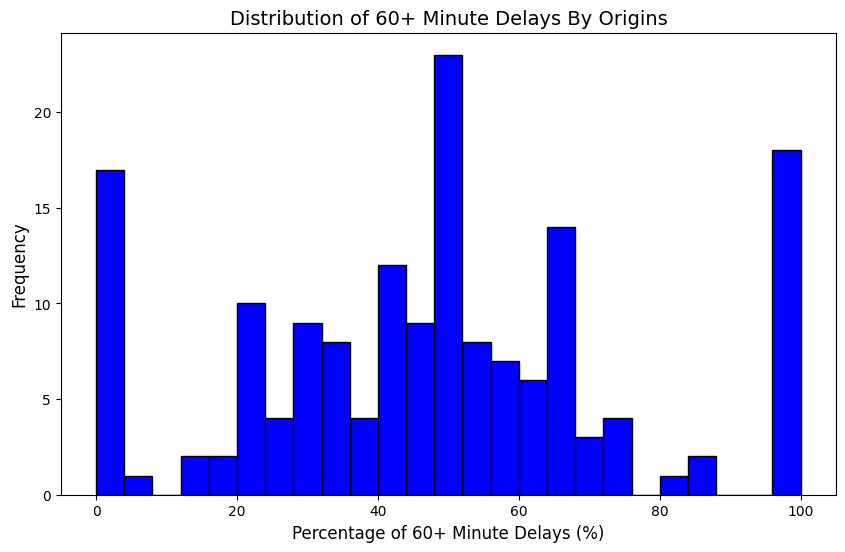

In [ ]:
# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(pct_delay_by_origin.values, bins=25, color='blue', edgecolor='black')

# Add labels and title
plt.title("Distribution of 60+ Minute Delays By Origins", fontsize=14)
plt.xlabel("Percentage of 60+ Minute Delays (%)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Show the plot
plt.show()

## Initialize and Fit the XGBoost classifier (baseline model)

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=0,
                              eval_metric='logloss')

In [ ]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Train the model
xgb_model.fit(X_train_resampled, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Create a DataFrame to compare actual and predicted values
comparison_df = pd.DataFrame({'Actual': y_train_resampled, 'Predicted': y_pred})
display(comparison_df.tail(10))

,Actual,Predicted
48171,1,1
14254,1,1
22626,1,1
34402,1,1
17591,1,1
15246,1,0
31921,1,1
27469,1,0
41993,1,1
30403,1,0


## Predict on the test set

In [ ]:
y_pred = xgb_model.predict(X_train_resampled )

## Evaluate the model

In [ ]:
print("XGBoost Classifier (Baseline):")
print(f"Accuracy: {accuracy_score(y_train_resampled, y_pred):.4f}")

XGBoost Classifier (Baseline):
Accuracy: 0.7976


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_train_resampled, y_pred)
cm

array([[2009,  513],
       [ 508, 2014]])

In [ ]:
# Predict probabilities for the test set (to calculate AUC)
y_pred_proba = xgb_model.predict_proba(X_train_resampled )[:, 1]  # We need probabilities for the positive class

# Calculate the AUC score
auc_score = roc_auc_score(y_train_resampled, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8890


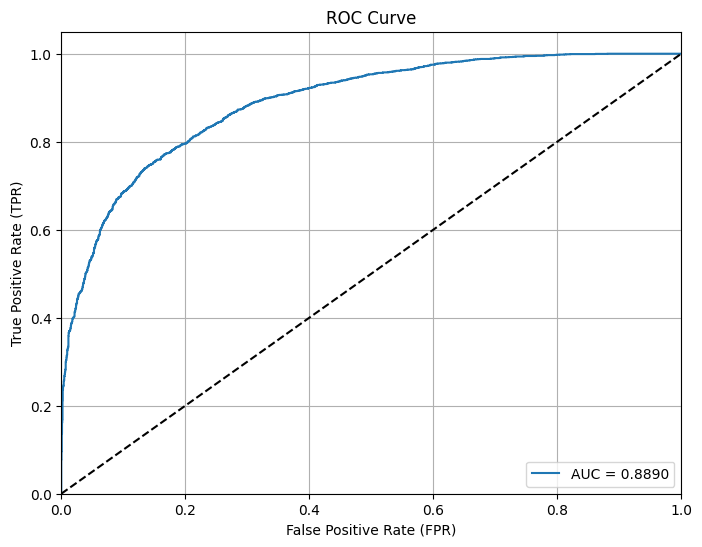

In [ ]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_train_resampled, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Do Cross-Validated Grid Search


In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 250],
    'subsample': [0.6,  1.0]
}

xgb_model = xgb.XGBClassifier(random_state=0,
                              eval_metric='logloss')

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=5, # Changed from 3 to 5 for 5-fold cross-validation
                           scoring='roc_auc',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_resampled , y_train_resampled)

# Display the cross-validation results
print("Cross-validation results:")
for i, (params, mean_score, std_score) in enumerate(zip(grid_search.cv_results_['params'],
                                                        grid_search.cv_results_['mean_test_score'],
                                                        grid_search.cv_results_['std_test_score'])):
    print(f"Candidate {i + 1}: {params} - Mean AUC: {mean_score:.4f} (Std: {std_score:.4f})")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Cross-validation results:
Candidate 1: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.6} - Mean AUC: 0.7039 (Std: 0.0057)
Candidate 2: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0} - Mean AUC: 0.6972 (Std: 0.0089)
Candidate 3: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 250, 'subsample': 0.6} - Mean AUC: 0.7112 (Std: 0.0066)
Candidate 4: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 250, 'subsample': 1.0} - Mean AUC: 0.7086 (Std: 0.0083)
Candidate 5: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.6} - Mean AUC: 0.7141 (Std: 0.0082)
Candidate 6: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0} - Mean AUC: 0.7115 (Std: 0.0119)
Candidate 7: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 250, 'subsample': 0.6} - Mean AUC: 0.7190 (Std: 0.0079)
Candidate 8: {'learning_rate': 0.01, 

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 250],
    'subsample': [0.6,  1.0]
}

xgb_model = xgb.XGBClassifier(random_state=0,
                              eval_metric='logloss')

grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=5, # Changed from 3 to 5 for 5-fold cross-validation
                           scoring='roc_auc',
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train_resampled , y_train_resampled)

# Display the cross-validation results
print("Cross-validation results:")
for i, (params, mean_score, std_score) in enumerate(zip(grid_search.cv_results_['params'],
                                                        grid_search.cv_results_['mean_test_score'],
                                                        grid_search.cv_results_['std_test_score'])):
    print(f"Candidate {i + 1}: {params} - Mean AUC: {mean_score:.4f} (Std: {std_score:.4f})")

## Evaluate best parameters and predict on training set

In [ ]:
# Best parameters from GridSearch
print("Best parameters found: ", grid_search.best_params_)

# Predict with the best model
y_pred_best = grid_search.best_estimator_.predict(X_train_resampled )

# Evaluate the tuned XGBoost model
print("XGBoost Classifier (Tuned):")
print(f"Accuracy: {accuracy_score(y_train_resampled, y_pred_best):.4f}")

Best parameters found:  {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 250, 'subsample': 0.6}
XGBoost Classifier (Tuned):
Accuracy: 0.7254


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_train_resampled, y_pred_best)
cm

array([[1800,  722],
       [ 663, 1859]])

In [ ]:
# Predict probabilities for the test set (to calculate AUC)
y_pred_proba = grid_search.best_estimator_.predict_proba(X_train_resampled )[:, 1]  # We need probabilities for the positive class

# Calculate the AUC score
auc_score = roc_auc_score(y_train_resampled, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8112


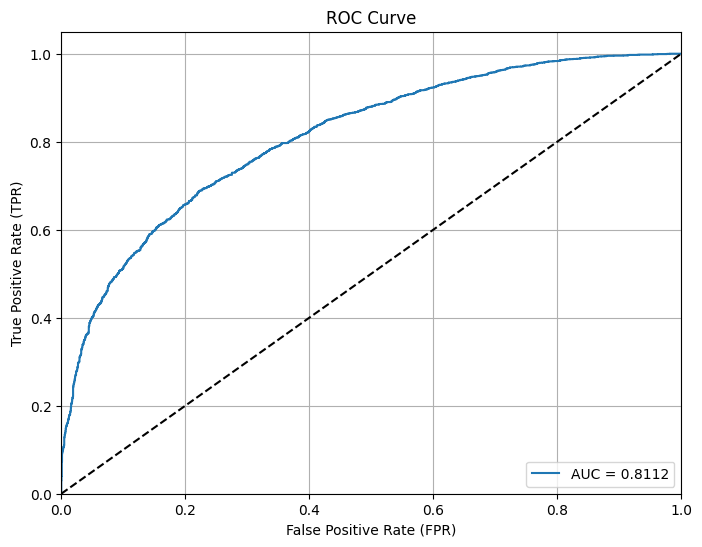

In [ ]:
# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_train_resampled, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random guessing
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()